**Assignment 1 - Sentinel-2 Spectral Indices Analysis**

The objective of this excercises is to set up your Python environment with the necessary packages and test it on a small remote sensing task. The tasks here are to read a Sentinel-2 satellite image and compute and visualize selected spectral indices.

**Load the necessary Python Packages**

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from osgeo import gdal, gdal_array
import rioxarray
import xarray

gdal.UseExceptions()

In [8]:
import rasterio
import os

print("Rasterio:", rasterio.__version__)
print("GDAL:", rasterio.__gdal_version__)
print("GDAL_DATA:", os.environ.get("GDAL_DATA"))

with rasterio.Env() as env:
    print("JP2OpenJPEG" in env.drivers())

Rasterio: 1.5.1
GDAL: 3.12.4
GDAL_DATA: None
True


In [9]:
import rasterio
print(rasterio.__version__)

with rasterio.Env() as env:
    print(env.drivers().keys())

1.5.1
dict_keys(['DERIVED', 'GTI', 'SNAP_TIFF', 'GTiff', 'COG', 'LIBERTIFF', 'VRT', 'NITF', 'RPFTOC', 'ECRGTOC', 'HFA', 'SAR_CEOS', 'CEOS', 'JAXAPALSAR', 'GFF', 'ESRIC', 'AIG', 'AAIGrid', 'GRASSASCIIGrid', 'ISG', 'DTED', 'PNG', 'JPEG', 'MEM', 'JDEM', 'GIF', 'BIGGIF', 'ESAT', 'BSB', 'BMP', 'DIMAP', 'AirSAR', 'RS2', 'SAFE', 'PCIDSK', 'PCRaster', 'ILWIS', 'SRTMHGT', 'Leveller', 'Terragen', 'netCDF', 'ISIS3', 'ISIS2', 'PDS', 'PDS4', 'VICAR', 'TIL', 'ERS', 'JP2OpenJPEG', 'L1B', 'GRIB', 'RMF', 'WCS', 'WMS', 'MSGN', 'RST', 'GSAG', 'GSBG', 'GS7BG', 'COSAR', 'TSX', 'COASP', 'MAP', 'KMLSUPEROVERLAY', 'WEBP', 'PDF', 'MBTiles', 'PLMOSAIC', 'CALS', 'WMTS', 'SENTINEL2', 'MRF', 'PNM', 'DOQ1', 'DOQ2', 'MFF', 'MFF2', 'GSC', 'FAST', 'BT', 'LAN', 'CPG', 'NDF', 'EIR', 'LCP', 'GTX', 'LOSLAS', 'NTv2', 'ACE2', 'SNODAS', 'KRO', 'ROI_PAC', 'RRASTER', 'BYN', 'NOAA_B', 'NSIDCbin', 'RIK', 'USGSDEM', 'GXF', 'BAG', 'S102', 'S104', 'S111', 'HDF5', 'HDF5Image', 'NWT_GRD', 'NWT_GRC', 'ADRG', 'SRP', 'SAGA', 'XYZ', 'HF2

This script uses Sentinel-2 imagery to investigate vegetation,
water bodies and urban surfaces using spectral indices.

Indices:<br>
NDVI - vegetation health<br>
EVI  - enhanced vegetation monitoring<br>
SAVI - vegetation index corrected for soil effects<br>
NDWI - water detection<br>
NDBI - built-up area detection


------------------------------------------------------------------
**1. LOAD DATA**
------------------------------------------------------------------

In [10]:
directory_path = os.path.join(os.getcwd(), 'data')
directory_path

'/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data'

In [11]:
# Locate Sentinel vrt_files
files = glob.glob(os.path.join(directory_path, "T32VNM_20220517T103631/*.tif"))
print(f"files found: {len(files)}")
files

files found: 11


['/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B08.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B08A.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B02.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B03.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B04.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B10.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B11.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_1/data/T32VNM_20220517T103631/B05.tif',
 '/Users/simenkrogstie/Documents/Programming/H26/GMFM35

In [12]:
fil = files[1]

In [17]:
raster = gdal.Open(fil)

In [18]:
# Check type of the variable 'raster'
type(raster)

osgeo.gdal.Dataset

**Read the Spatial reference system and projection, dimension, number of bands and other metadata of the image.**

In [19]:
raster.GetProjection()

'PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]'

In [20]:
# Dimensions
raster.RasterXSize, raster.RasterYSize

(10980, 10980)

In [21]:
# Number of bands
raster.RasterCount

1

In [22]:
# Metadata for the raster dataset
raster.GetMetadata()

{'AREA_OR_POINT': 'Area'}

**Read a band from the raster dataset as array and compute band statistics.**

In [23]:
# Read the raster band as separate variable
band = raster.GetRasterBand(1)
# Check type of the variable 'band'
print(type(band))

<class 'osgeo.gdal.Band'>


In [24]:
# Data type of the values
gdal.GetDataTypeName(band.DataType)

'UInt16'

In [25]:
#Read the band as a numeric array
B1 = band.ReadAsArray()
B1

array([[3321, 3321, 3436, ..., 3061, 3139, 3139],
       [3321, 3321, 3436, ..., 3061, 3139, 3139],
       [3376, 3376, 3216, ..., 3030, 2888, 2888],
       ...,
       [3715, 3715, 3855, ..., 3691, 3461, 3461],
       [3749, 3749, 3707, ..., 3918, 3632, 3632],
       [3749, 3749, 3707, ..., 3918, 3632, 3632]],
      shape=(10980, 10980), dtype=uint16)

In [26]:
# Compute statistics if needed
if band.GetMinimum() is not None or band.GetMaximum() is not None:
    band.ComputeStatistics(0)
    print("Statistics computed.")

Statistics computed.


In [27]:
# Fetch metadata for the band
band.GetMetadata()

{'STATISTICS_MAXIMUM': '16570',
 'STATISTICS_MEAN': '3004.8335216207',
 'STATISTICS_MINIMUM': '0',
 'STATISTICS_STDDEV': '807.9201563789',
 'STATISTICS_VALID_PERCENT': '100'}

In [28]:
# Print only selected metadata:
print ("[ NO DATA VALUE ] = ", band.GetNoDataValue()) # none
print ("[ MIN ] = ", band.GetMinimum())
print ("[ MAX ] = ", band.GetMaximum())

[ NO DATA VALUE ] =  None
[ MIN ] =  0.0
[ MAX ] =  16570.0


In [29]:
# Read the entire raster data as numeric array from GDAL Dataset
rasterArray = raster.ReadAsArray()

In [30]:
rasterArray.shape

(10980, 10980)

In [31]:
#Check the datatype of variables
type(rasterArray), type(raster)

(numpy.ndarray, osgeo.gdal.Dataset)

The GDAL library also comes with a module called gdal_array that works as an interface between NumPy and GDAL. Gdal_array reads and writes raster files to and from NumPy arrays directly from file:


In [32]:
# Read raster data as numeric array from file
rasterArray = gdal_array.LoadFile(fil)

In [33]:
rasterArray.shape

(10980, 10980)

In [34]:
rasterArray.min()

np.uint16(0)

In [35]:
# Get nodata value from the GDAL band object
nodata = band.GetNoDataValue()
print(nodata)
if nodata == None:
    nodata=0
#Create a masked array for making calculations without nodata values
rasterArray = np.ma.masked_equal(rasterArray, nodata)
print(type(rasterArray))

# Check again array statistics
rasterArray.min()

None
<class 'numpy.ma.MaskedArray'>


np.uint16(1)

**Close all the datasets.**

In [36]:
raster = None
ds     = None
band   = None

In [37]:
das = [rioxarray.open_rasterio(f) for f in files]
da  = xarray.concat(das, dim="band")
da  = da.assign_coords(band=[os.path.basename(f).split(".")[0] for f in files])

In [38]:
# Open and read raster metadata
#da = rioxarray.open_rasterio(files[:])
#da

In [39]:
# Extract a smaller subset to reduce memory usage
subset = da[:, 4000:4500, 4000:4500].load()
subset

<xarray.DataArray (band: 11, y: 500, x: 500)> Size: 6MB
array([[[2964, 2916, 3128, ..., 2940, 2835, 2844],
        [3236, 2964, 3024, ..., 2797, 2765, 2770],
        [3459, 3248, 3094, ..., 2810, 2748, 2710],
        ...,
        [3158, 3026, 2902, ..., 2749, 2770, 2675],
        [2926, 2748, 2798, ..., 2928, 2737, 2462],
        [2859, 2779, 2656, ..., 2848, 2717, 2687]],

       [[3065, 3065, 3154, ..., 2885, 2839, 2839],
        [3065, 3065, 3154, ..., 2885, 2839, 2839],
        [3264, 3264, 3200, ..., 2824, 2789, 2789],
        ...,
        [2966, 2966, 2943, ..., 2883, 2863, 2863],
        [2898, 2898, 2883, ..., 2823, 2773, 2773],
        [2898, 2898, 2883, ..., 2823, 2773, 2773]],

       [[1198, 1244, 1328, ..., 1333, 1265, 1266],
        [1268, 1207, 1323, ..., 1275, 1247, 1273],
        [1409, 1345, 1356, ..., 1352, 1330, 1243],
        ...,
...
        [2767, 2767, 2737, ..., 2670, 2599, 2599],
        [2738, 2738, 2612, ..., 2688, 2600, 2600],
        [2738, 2738, 2612, ..., 2688, 2600, 2600]],

       [[2602, 2602, 2669, ..., 2488, 2479, 2479],
        [2602, 2602, 2669, ..., 2488, 2479, 2479],
        [2729, 2729, 2640, ..., 2509, 2423, 2423],
        ...,
        [2521, 2521, 2605, ..., 2438, 2447, 2447],
        [2473, 2473, 2459, ..., 2502, 2379, 2379],
        [2473, 2473, 2459, ..., 2502, 2379, 2379]],

       [[1888, 1888, 2112, ..., 1783, 1776, 1776],
        [1888, 1888, 2112, ..., 1783, 1776, 1776],
        [2044, 2044, 2261, ..., 1855, 1787, 1787],
        ...,
        [1965, 1965, 1854, ..., 1603, 1652, 1652],
        [1805, 1805, 1726, ..., 1597, 1632, 1632],
        [1805, 1805, 1726, ..., 1597, 1632, 1632]]],
      shape=(11, 500, 500), dtype=uint16)
Coordinates:
  * band         (band) <U4 176B 'B08' 'B08A' 'B02' 'B03' ... 'B07' 'B06' 'B12'
  * y            (y) float64 4kB 6.66e+06 6.66e+06 ... 6.655e+06 6.655e+06
  * x            (x) float64 4kB 5.4e+05 5.4e+05 5.4e+05 ... 5.45e+05 5.45e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        9280
    STATISTICS_MEAN:           2968.2339828848
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         832.26203103004
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

------------------------------------------------------------------
**2. RGB VISUALIZATION**
------------------------------------------------------------------

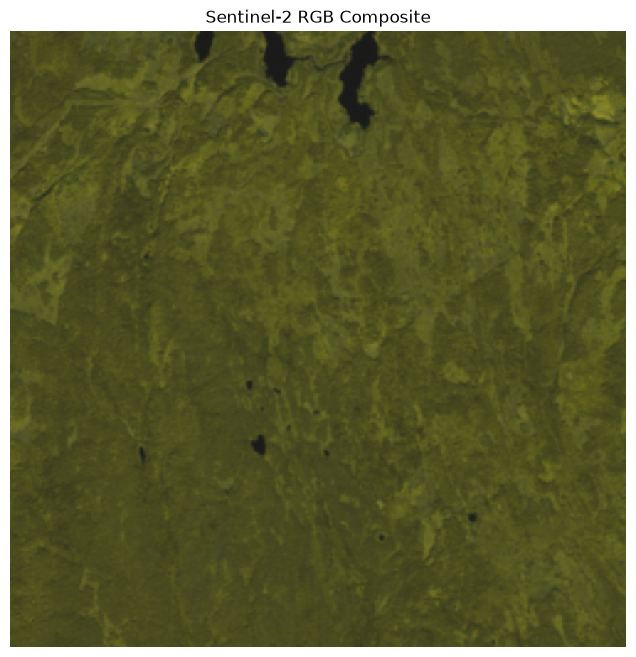

In [57]:
# RGB visualization
rgb = subset.data[:3, :, :].transpose(1, 2, 0)
plt.figure(figsize=(8,8))
plt.imshow(rgb/10000)
plt.title('Sentinel-2 RGB Composite')
plt.axis('off')
plt.show()

------------------------------------------------------------------
**3. BAND DEFINITIONS**
------------------------------------------------------------------

In [58]:
# Sentinel-2 bands
BLUE  = subset[0].astype(float)
GREEN = subset[1].astype(float)
RED   = subset[2].astype(float)
NIR   = subset[7].astype(float)
SWIR  = subset[10].astype(float)
EPS   = 0.0000001 #1e-10
RED.shape

(500, 500)

------------------------------------------------------------------
**4. SPECTRAL INDICES**
------------------------------------------------------------------

In [59]:
# NDVI
# NDVI = (NIR - Red)/(NIR + Red)
# Healthy vegetation reflects NIR strongly and absorbs red light.
# Values >0.5 typically indicate dense vegetation.
NDVI = (NIR - RED)/(NIR + RED)# + EPS)
NDVI

<xarray.DataArray (y: 500, x: 500)> Size: 2MB
array([[0.22005208, 0.2020526 , 0.22270998, ..., 0.14386641, 0.17401241,
        0.17362924],
       [0.19287078, 0.21648815, 0.22450176, ..., 0.16557592, 0.18095238,
        0.17095409],
       [0.18389806, 0.20625553, 0.22469983, ..., 0.16129032, 0.14606742,
        0.17899604],
       ...,
       [0.17034196, 0.19516971, 0.18334453, ..., 0.18392795, 0.19108062,
        0.18660287],
       [0.16318274, 0.16593444, 0.16479017, ..., 0.18382861, 0.18706537,
        0.19621584],
       [0.18883529, 0.16790792, 0.15807327, ..., 0.18958333, 0.19203911,
        0.18172378]], shape=(500, 500))
Coordinates:
  * y            (y) float64 4kB 6.66e+06 6.66e+06 ... 6.655e+06 6.655e+06
  * x            (x) float64 4kB 5.4e+05 5.4e+05 5.4e+05 ... 5.45e+05 5.45e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        9280
    STATISTICS_MEAN:           2968.2339828848
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         832.26203103004
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

In [60]:
# EVI
# Enhanced Vegetation Index.
# More resistant to atmospheric effects and saturation than NDVI.
EVI = 2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1 + EPS))

In [61]:
# SAVI
# Soil Adjusted Vegetation Index.
# Reduces influence of exposed soil.
L = 0.5
SAVI = ((NIR - RED + 0.0) / (NIR + RED + L + EPS)) * (1 + L)

In [62]:
# NDWI
# Water index.
# Water absorbs NIR strongly and often produces positive values.
NDWI = (GREEN - NIR) / (GREEN + NIR + EPS)

In [63]:
# NDBI
# Built-up index.
# Positive values often correspond to urban surfaces.
NDBI = (SWIR - NIR) / (SWIR + NIR + EPS)

In [64]:
indices = {
    'NDVI':(NDVI,'RdYlGn'),
    'EVI':(EVI,'RdYlGn'),
    'SAVI':(SAVI,'RdYlGn'),
    'NDWI':(NDWI,'Blues'),
    'NDBI':(NDBI,'RdYlGn_r')
}

NDVI: min=-0.041, max=0.354


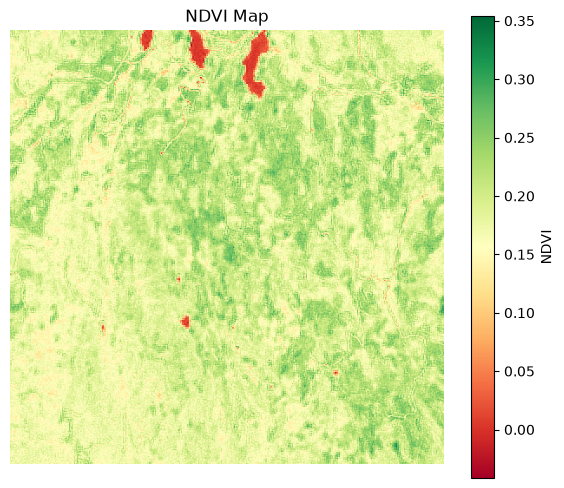

EVI: min=-2.817, max=0.233


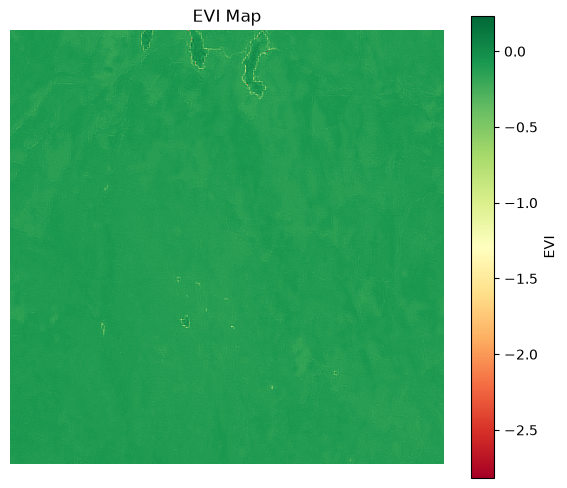

SAVI: min=-0.062, max=0.531


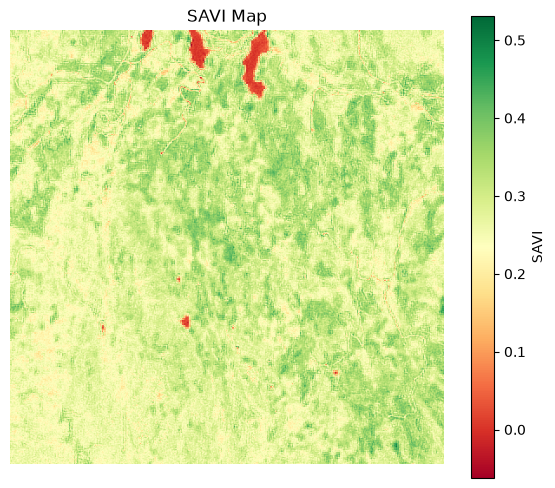

NDWI: min=-0.036, max=0.409


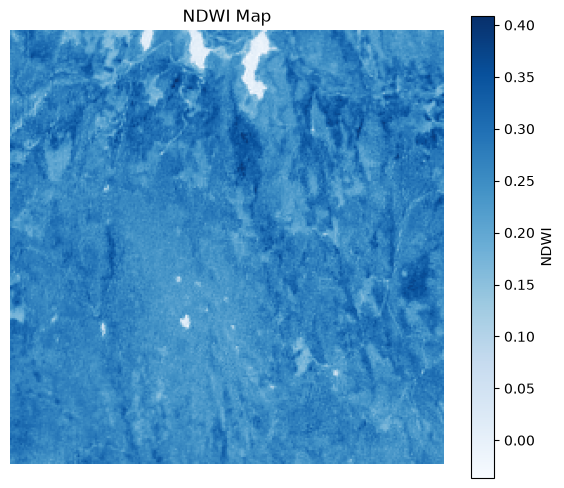

NDBI: min=-0.204, max=0.225


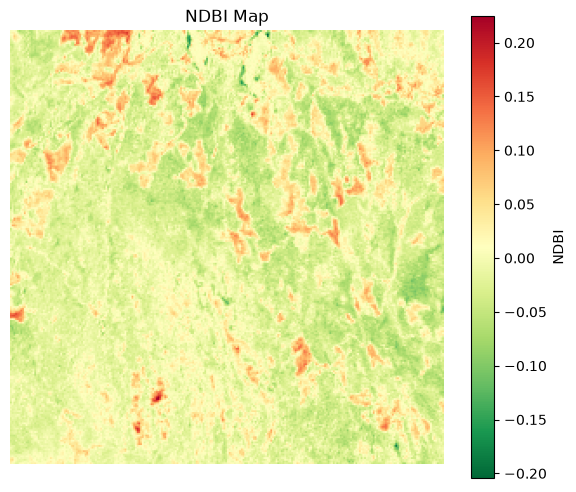

In [65]:
for name,(img,cmap) in indices.items():
    print(f'{name}: min={float(img.min()):.3f}, max={float(img.max()):.3f}')
    plt.figure(figsize=(7,6))
    plt.imshow(img, cmap=cmap)
    plt.colorbar(label=name)
    plt.title(f'{name} Map')
    plt.axis('off')
    plt.show()

------------------------------------------------------------------
**5. CORRELATION ANALYSIS**
------------------------------------------------------------------

In [66]:
# Correlation analysis
results = pd.DataFrame({
    'NDVI':NDVI.values.flatten(),
    'EVI':EVI.values.flatten(),
    'SAVI':SAVI.values.flatten(),
    'NDWI':NDWI.values.flatten(),
    'NDBI':NDBI.values.flatten()
})

In [67]:
results = results.replace([np.inf, -np.inf], np.nan).dropna()

In [68]:
corr_matrix = results.corr()
print(corr_matrix)

          NDVI       EVI      SAVI      NDWI      NDBI
NDVI  1.000000 -0.415530  1.000000  0.203863 -0.008467
EVI  -0.415530  1.000000 -0.415539  0.392987 -0.272055
SAVI  1.000000 -0.415539  1.000000  0.203822 -0.008423
NDWI  0.203863  0.392987  0.203822  1.000000 -0.531144
NDBI -0.008467 -0.272055 -0.008423 -0.531144  1.000000


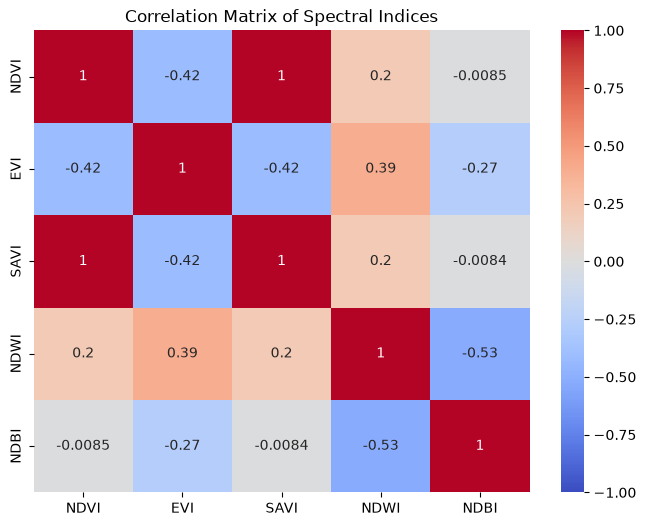

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Spectral Indices')
plt.show()

------------------------------------------------------------------
**6. HISTOGRAMS**
------------------------------------------------------------------

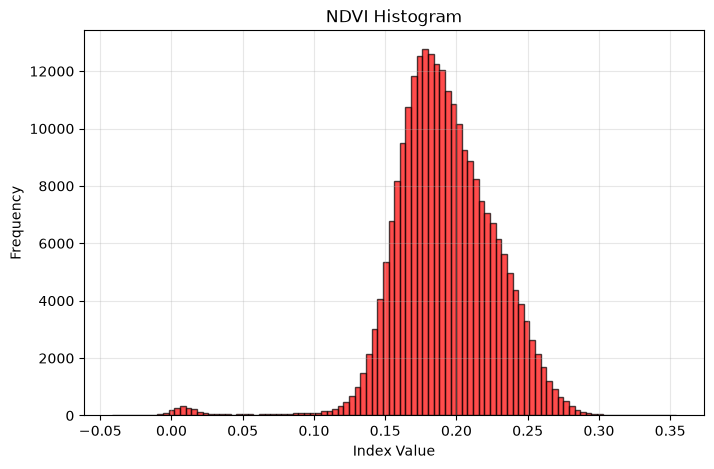

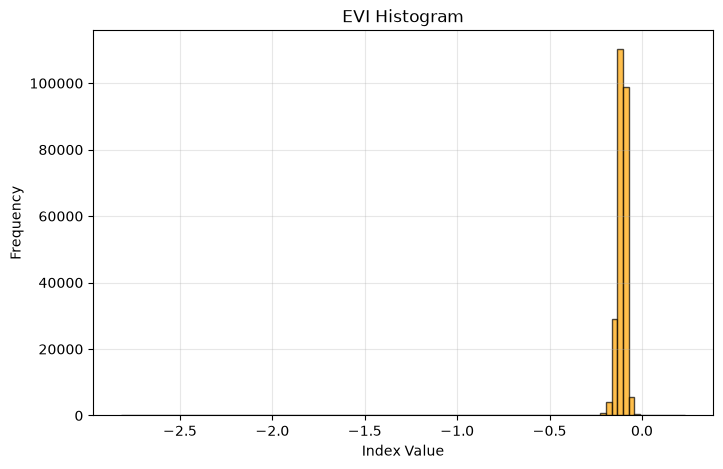

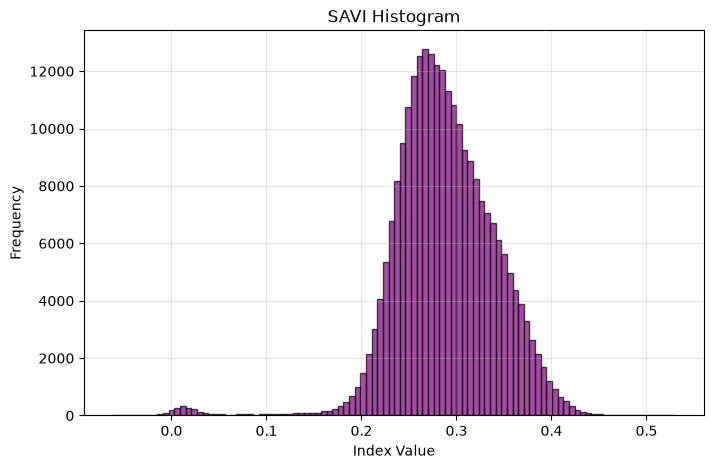

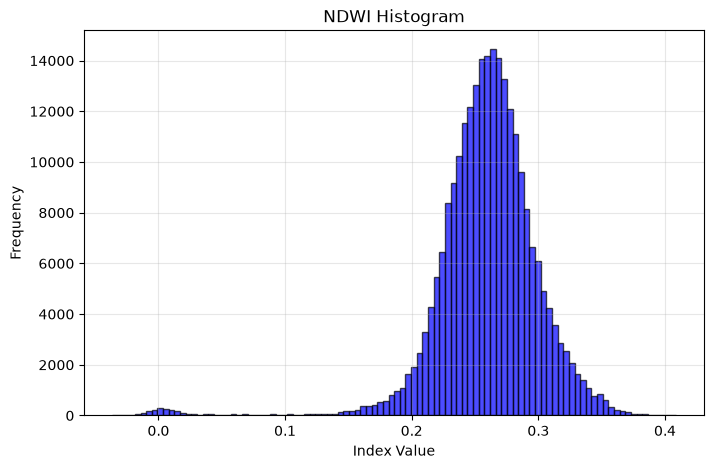

In [70]:
# Histograms
for col,color in {
    'NDVI':'green','EVI':'orange','SAVI':'purple','NDWI':'blue','NDVI':'red'
}.items():
    plt.figure(figsize=(8,5))
    plt.hist(results[col], bins=100, color=color, alpha=0.7, edgecolor='black')
    plt.title(f'{col} Histogram')
    plt.xlabel('Index Value')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

In [71]:
print('Analysis completed successfully.')

Analysis completed successfully.
